# Pipeline v4 — Géométrie dans l'espace projeté

## Idée centrale

Projetez image et texte dans le **même espace latent** via CCA/PLSSVD,
puis raisonnez uniquement sur la **géométrie** entre les deux vecteurs :

```
   espace latent (dim K)
   ┌───────────────────────────────┐
   │   v_img ──────┐              │
   │               angle θ        │
   │   v_txt ──────┘  distance d  │
   └───────────────────────────────┘
```

**Cohérent** → angle faible, distance faible
**Incohérent** → angle élevé, distance élevée

Le modèle classique apprend cette frontière sur (θ, d, ...) uniquement.
100% classique, 100% interprétable.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Cell 1 — Dépendances
# ═══════════════════════════════════════════════════════════════════
!pip install opencv-python scikit-image vaderSentiment joblib --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ═══════════════════════════════════════════════════════════════════
# Cell 2 — Imports
# ═══════════════════════════════════════════════════════════════════
import os, warnings, time, copy, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import nltk
from nltk.stem import PorterStemmer

from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import io, transform
from skimage.filters import threshold_otsu, threshold_local, scharr
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from scipy import ndimage as ndi
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import cosine
from scipy import sparse

from joblib import Parallel, delayed, Memory
import multiprocessing
N_JOBS = max(1, multiprocessing.cpu_count() - 1)
memory = Memory('./joblib_cache_v4g', verbose=0)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cross_decomposition import CCA, PLSCanonical, PLSSVD
from sklearn.decomposition import PCA, IncrementalPCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_OK = True
    vader = SentimentIntensityAnalyzer()
except ImportError:
    VADER_OK = False

warnings.filterwarnings('ignore')
# Use the Docker-installed NLTK data directory if available.
nltk_data_dir = os.environ.get('NLTK_DATA', '/usr/local/share/nltk_data')
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ']+")
stemmer = PorterStemmer()
STOP = set(ENGLISH_STOP_WORDS)
print(f'Parallélisme : {N_JOBS} workers')
print('Imports OK — Pipeline v4 Géométrique')

Parallélisme : 7 workers
Imports OK — Pipeline v4 Géométrique


In [3]:
# ═══════════════════════════════════════════════════════════════════
# Cell 3 — Chargement données
# ═══════════════════════════════════════════════════════════════════
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f'Dossier {folder} non trouvé.')
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    texts, img_paths, labels = shuffle(texts, img_paths,
                                        np.array(labels), random_state=42)
    return np.array(texts), np.array(img_paths), labels

print('Chargement...')
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')

print(f'Train : {len(t_train)} | Val : {len(t_val)} | Test : {len(t_test)}')
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print(f'Class weights : {CLASS_WEIGHT}')

Chargement...
Train : 7000 | Val : 1500 | Test : 1500
Class weights : {0: np.float64(1.003440366972477), 1: np.float64(0.9965831435079726)}


In [4]:
# ═══════════════════════════════════════════════════════════════════
# Cell 4 — Extraction features image (HOG + LBP + couleur + spatial)
# ═══════════════════════════════════════════════════════════════════
IMG_SIZE   = (192, 192)
GRID_N     = 3
HOG_PIXELS = 8
LBP_RADIUS = 2
LBP_POINTS = 8 * LBP_RADIUS
N_HSV_BINS = 16

def load_image(img_path):
    img = io.imread(img_path)
    if img.ndim == 2:      img = np.stack([img]*3, axis=-1)
    if img.shape[2] == 4:  img = img[:,:,:3]
    img  = (transform.resize(img, IMG_SIZE, anti_aliasing=True)*255).astype(np.uint8)
    return img, rgb2gray(img), cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

def features_per_zone(zg, zr, zh):
    hog_f = hog(zg, orientations=8,
                pixels_per_cell=(HOG_PIXELS,HOG_PIXELS),
                cells_per_block=(2,2), feature_vector=True)
    h_h = np.histogram(zh[:,:,0], bins=N_HSV_BINS, range=(0,180))[0].astype(float)
    s_h = np.histogram(zh[:,:,1], bins=N_HSV_BINS, range=(0,256))[0].astype(float)
    v_h = np.histogram(zh[:,:,2], bins=N_HSV_BINS, range=(0,256))[0].astype(float)
    hsv_f = np.concatenate([h_h, s_h, v_h])
    hsv_f /= (hsv_f.sum() + 1e-8)
    lbp   = local_binary_pattern(zg, LBP_POINTS, LBP_RADIUS, method='uniform')
    lbp_f = np.histogram(lbp, bins=LBP_POINTS+2, range=(0,LBP_POINTS+2))[0].astype(float)
    lbp_f /= (lbp_f.sum() + 1e-8)
    stats = np.array([zg.mean(), zg.std(), zr.mean(axis=(0,1)).mean(), zh[:,:,1].mean()])
    return np.concatenate([hog_f, hsv_f, lbp_f, stats])

def compute_saliency(gray):
    g8  = (gray*255).astype(np.float32)
    fft = np.fft.fft2(g8)
    la  = np.log(np.abs(fft)+1e-8)
    sm  = cv2.filter2D(la, -1, np.ones((3,3),np.float32)/9)
    rec = np.fft.ifft2(np.exp(la-sm+1j*np.angle(fft))).real
    sal = cv2.GaussianBlur(rec**2, (9,9), 2.5)
    return (sal-sal.min())/(sal.max()-sal.min()+1e-8)

@memory.cache
def extract_img_features(img_path):
    try:
        img, gray, hsv = load_image(img_path)
        h, w   = img.shape[:2]
        zh, zw = h//GRID_N, w//GRID_N
        half_h, half_w = h//2, w//2

        zone_feats = []
        for r in range(GRID_N):
            for c in range(GRID_N):
                zone_feats.append(features_per_zone(
                    gray[r*zh:(r+1)*zh, c*zw:(c+1)*zw],
                    img [r*zh:(r+1)*zh, c*zw:(c+1)*zw],
                    hsv [r*zh:(r+1)*zh, c*zw:(c+1)*zw]))

        canny  = cv2.Canny((gray*255).astype(np.uint8),50,150).astype(float)/255
        sal    = compute_saliency(gray)
        otsu   = (gray > threshold_otsu(gray)).astype(float)

        def zm(arr):
            return arr[:GRID_N*zh,:GRID_N*zw].reshape(GRID_N,zh,GRID_N,zw).mean(axis=(1,3)).ravel()

        cny = np.argwhere(canny>0.5)
        cy_n = cny[:,0].mean()/h if len(cny)>0 else 0.5
        cx_n = cny[:,1].mean()/w if len(cny)>0 else 0.5

        top_hue = hsv[:half_h,:,0].mean()/180
        bot_hue = hsv[half_h:,:,0].mean()/180
        top_sat = hsv[:half_h,:,1].mean()/255
        bot_sat = hsv[half_h:,:,1].mean()/255

        hog_g = hog(gray, orientations=9, pixels_per_cell=(16,16),
                    cells_per_block=(2,2), feature_vector=True)

        scalars = np.array([
            cy_n, cx_n,
            canny[:,:half_w].mean()-canny[:,half_w:].mean(),
            canny[:half_h,:].mean()-canny[half_h:,:].mean(),
            sal[:half_h,:].mean()-sal[half_h:,:].mean(),
            top_hue, bot_hue, top_hue-bot_hue,
            top_sat, bot_sat, top_sat-bot_sat,
            scipy_entropy(zm(sal)+1e-8),
            sal.mean(), sal.std(), sal.max(),
            canny.mean(), otsu.mean(),
            gray.mean(), gray.std(),
        ])
        return np.concatenate([np.concatenate(zone_feats),
                                zm(canny), zm(sal), zm(otsu),
                                scalars, hog_g])
    except Exception as e:
        print(f'Erreur {img_path}: {e}')
        return np.zeros(600)

print('Extraction features image...')
F_img_train = np.array(Parallel(n_jobs=N_JOBS)(
    delayed(extract_img_features)(p) for p in p_train))
F_img_val   = np.array(Parallel(n_jobs=N_JOBS)(
    delayed(extract_img_features)(p) for p in p_val))
F_img_test  = np.array(Parallel(n_jobs=N_JOBS)(
    delayed(extract_img_features)(p) for p in p_test))
print(f'  Shape image train : {F_img_train.shape}')

Extraction features image...
  Shape image train : (7000, 19144)


In [5]:
# ═══════════════════════════════════════════════════════════════════
# Cell 5 — Extraction features texte
# ═══════════════════════════════════════════════════════════════════
def preprocess(text):
    tokens = TOKEN_PATTERN.findall(text.lower())
    return ' '.join(stemmer.stem(t)
                    for t in tokens if t.isalpha() and t not in STOP)

print('TF-IDF...')

t_tr_clean = [preprocess(t) for t in t_train]
t_va_clean = [preprocess(t) for t in t_val]
t_te_clean = [preprocess(t) for t in t_test]

# Keep TF-IDF as sparse to save memory
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
T_train = tfidf.fit_transform(t_tr_clean)
T_val   = tfidf.transform(t_va_clean)
T_test  = tfidf.transform(t_te_clean)

SKW = ['sky','cloud','tree','grass','water','sea','ocean','mountain',
       'city','street','building','road','car','person','people',
       'top','bottom','left','right','center','above','below']

def text_extras(text):
    toks = set(TOKEN_PATTERN.findall(text.lower()))
    kw   = np.array([1.0 if w in toks else 0.0 for w in SKW])
    sent = np.zeros(4)
    if VADER_OK:
        s    = vader.polarity_scores(text)
        sent = np.array([s['pos'], s['neg'], s['neu'], s['compound']])
    words = TOKEN_PATTERN.findall(text)
    stats = np.array([len(words),
                       len(set(words)),
                       np.mean([len(w) for w in words]) if words else 0,
                       len(set(words))/(len(words)+1e-8)])
    return np.concatenate([kw, sent, stats])

E_train = np.array([text_extras(t) for t in t_train])
E_val   = np.array([text_extras(t) for t in t_val])
E_test  = np.array([text_extras(t) for t in t_test])

# Stack sparse TF-IDF with dense extras by converting extras to sparse
E_train_sp = sparse.csr_matrix(E_train)
E_val_sp   = sparse.csr_matrix(E_val)
E_test_sp  = sparse.csr_matrix(E_test)

Ft_train = sparse.hstack([T_train, E_train_sp], format='csr')
Ft_val   = sparse.hstack([T_val,   E_val_sp], format='csr')
Ft_test  = sparse.hstack([T_test,  E_test_sp], format='csr')

print('  Text sparse shapes:', Ft_train.shape)

# Keep original dense E arrays if needed elsewhere
F_txt_train = None
F_txt_val = None
F_txt_test = None
print('  Shape texte (sparse) :', Ft_train.shape)

TF-IDF...
  Text sparse shapes: (7000, 8030)
  Shape texte (sparse) : (7000, 8030)


In [6]:
# ═══════════════════════════════════════════════════════════════════
# Cell 6 — Nettoyage + PCA pré-projection
# ═══════════════════════════════════════════════════════════════════

def remove_correlated(X, thr=0.95):
    X_s = X[:min(500, len(X))]
    corr = np.corrcoef(X_s.T)
    np.fill_diagonal(corr, 0)
    drop = set()
    for i in range(corr.shape[0]):
        if i in drop:
            continue
        for j in range(i+1, corr.shape[1]):
            if abs(corr[i, j]) > thr:
                drop.add(j)
    return [i for i in range(X.shape[1]) if i not in drop]

print('Nettoyage features...')

# Cast large image features to float32 to save memory
F_img_train = F_img_train.astype(np.float32)
F_img_val   = F_img_val.astype(np.float32)
F_img_test  = F_img_test.astype(np.float32)

# Reduce text dimensionality with TruncatedSVD (works with sparse input)
K_pre = 150
try:
    print('TruncatedSVD on text (sparse) ...')
    svd_t = TruncatedSVD(n_components=min(K_pre, Ft_train.shape[1]), n_iter=7, random_state=42)
    Pt_tr = svd_t.fit_transform(Ft_train)
    Pt_va = svd_t.transform(Ft_val)
    Pt_te = svd_t.transform(Ft_test)
    print('  Pt_tr shape:', Pt_tr.shape)
except Exception as e:
    print('TruncatedSVD failed:', e)
    raise

# For images, apply VarianceThreshold and IncrementalPCA to avoid full-memory PCA
try:
    vt_i = VarianceThreshold(1e-6)
    Fi_tr = vt_i.fit_transform(F_img_train)
    Fi_va = vt_i.transform(F_img_val)
    Fi_te = vt_i.transform(F_img_test)
except Exception as e:
    print('VarianceThreshold on images failed:', e)
    raise

# Standardize
sc_i = StandardScaler()
sc_t = StandardScaler()
Fi_tr = sc_i.fit_transform(Fi_tr)
Fi_va = sc_i.transform(Fi_va)
Fi_te = sc_i.transform(Fi_te)

# Remove highly correlated image features
ki = remove_correlated(Fi_tr)
Fi_tr = Fi_tr[:, ki]
Fi_va = Fi_va[:, ki]
Fi_te = Fi_te[:, ki]
print(f'  Image après dédup : {len(ki)}')

# PCA for images using IncrementalPCA
pca_i = IncrementalPCA(n_components=min(K_pre, Fi_tr.shape[1]), batch_size=200)
Pi_tr = pca_i.fit_transform(Fi_tr)
Pi_va = pca_i.transform(Fi_va)
Pi_te = pca_i.transform(Fi_te)

print(f'  PCA image : {Pi_tr.shape[1]} dims')
print(f'  PCA texte : {Pt_tr.shape[1]} dims')

Nettoyage features...
TruncatedSVD on text (sparse) ...
  Pt_tr shape: (7000, 150)
  Image après dédup : 19006
  PCA image : 150 dims
  PCA texte : 150 dims


In [7]:
# ═══════════════════════════════════════════════════════════════════
# Cell 7 — Projections dans l'espace commun
#
# On compare TROIS méthodes de projection :
#   CCA      : maximise la corrélation canonique
#   PLSSVD   : maximise la covariance croisée (plus stable, moins
#               sensible au bruit que CCA)
#   PLSCanonical : variante symétrique de PLS (mode B)
#
# Pour chacune, on projette image → V_img  et texte → V_txt
# puis on calcule les features géométriques.
# ═══════════════════════════════════════════════════════════════════
K_proj = 64  # dimensions de l'espace commun

projectors = {}

# ── CCA ──────────────────────────────────────────────────────────
print('CCA...')
cca = CCA(n_components=K_proj, max_iter=2000, tol=1e-6)
cca.fit(Pt_tr, Pi_tr)
projectors['CCA'] = cca

# ── PLSCanonical ─────────────────────────────────────────────────
print('PLSCanonical...')
plsc = PLSCanonical(n_components=K_proj, max_iter=2000, tol=1e-6)
plsc.fit(Pt_tr, Pi_tr)
projectors['PLSCanonical'] = plsc

# ── PLSSVD ───────────────────────────────────────────────────────
print('PLSSVD...')
plssvd = PLSSVD(n_components=min(K_proj, min(Pt_tr.shape)))
plssvd.fit(Pt_tr, Pi_tr)
projectors['PLSSVD'] = plssvd

# Corrélations canoniques (qualité de la projection)
print('\nCorrélations canoniques CCA (top 10):')
Vt_cca, Vi_cca = cca.transform(Pt_tr, Pi_tr)
for i in range(min(10, K_proj)):
    r = np.corrcoef(Vt_cca[:,i], Vi_cca[:,i])[0,1]
    print(f'  C{i+1:02d}: r={r:.4f}')

CCA...
PLSCanonical...
PLSSVD...

Corrélations canoniques CCA (top 10):
  C01: r=0.3962
  C02: r=0.3716
  C03: r=0.3271
  C04: r=0.3172
  C05: r=0.3021
  C06: r=0.2987
  C07: r=0.2859
  C08: r=0.2803
  C09: r=0.2718
  C10: r=0.2696


In [8]:
# ═══════════════════════════════════════════════════════════════════
# Cell 8 — Calcul des features géométriques
#
# C'est le coeur du pipeline :
# Pour chaque paire (image, texte), on a deux vecteurs dans l'espace
# commun : v_img et v_txt.
# On calcule TOUTES les mesures géométriques entre eux.
# ═══════════════════════════════════════════════════════════════════

def geometric_features(v_txt, v_img):
    """
    Calcule les features géométriques entre deux vecteurs
    dans l'espace de projection commun.

    v_txt, v_img : arrays 1D de dimension K
    Retourne un vecteur de features scalaires + décomposition par composante.
    """
    eps = 1e-8
    diff   = v_txt - v_img
    norm_t = np.linalg.norm(v_txt) + eps
    norm_i = np.linalg.norm(v_img) + eps

    # ── 1. Distances ───────────────────────────────────────────────
    d_euclidean   = np.linalg.norm(diff)
    d_manhattan   = np.sum(np.abs(diff))
    d_chebyshev   = np.max(np.abs(diff))
    d_cosine      = float(cosine(v_txt, v_img))  # 0=parallèle, 2=opposés

    # ── 2. Angle ───────────────────────────────────────────────────
    cos_sim       = np.dot(v_txt, v_img) / (norm_t * norm_i)
    cos_sim       = np.clip(cos_sim, -1.0, 1.0)
    angle_rad     = np.arccos(cos_sim)          # [0, π]
    angle_deg     = np.degrees(angle_rad)

    # ── 3. Projection / composante orthogonale ─────────────────────
    # proj de v_txt sur v_img (scalaire)
    proj_scalar   = np.dot(v_txt, v_img) / norm_i
    # vecteur projeté
    proj_vec      = proj_scalar * v_img / norm_i
    # composante orthogonale
    orth_vec      = v_txt - proj_vec
    orth_norm     = np.linalg.norm(orth_vec)    # 0 = parfaitement alignés

    # ── 4. Normes relatives ─────────────────────────────────────────
    norm_ratio    = norm_t / norm_i             # 1.0 = même ampleur
    dot_product   = np.dot(v_txt, v_img)

    # ── 5. Statistiques sur la différence ──────────────────────────
    diff_mean = diff.mean()
    diff_std  = diff.std()
    diff_max  = diff.max()
    diff_min  = diff.min()

    # ── 6. Corrélation de Pearson ──────────────────────────────────
    if len(v_txt) > 2 and v_txt.std() > eps and v_img.std() > eps:
        pearson_r = np.corrcoef(v_txt, v_img)[0,1]
    else:
        pearson_r = 0.0

    # ── 7. Entropie de la distribution d'énergie ───────────────────
    energy_t  = v_txt**2 / (np.sum(v_txt**2) + eps)
    energy_i  = v_img**2 / (np.sum(v_img**2) + eps)
    ent_t     = scipy_entropy(energy_t + eps)
    ent_i     = scipy_entropy(energy_i + eps)
    ent_ratio = ent_t / (ent_i + eps)

    # ── 8. Produit élémentaire (alignement dim par dim) ────────────
    product   = v_txt * v_img          # vecteur K
    pos_align = (product > 0).mean()   # fraction de dims qui s'accordent en signe
    abs_diff  = np.abs(diff)           # vecteur K

    # ── Scalaires récapitulatifs ───────────────────────────────────
    scalars = np.array([
        d_euclidean,           # distance L2
        d_manhattan,           # distance L1
        d_chebyshev,           # distance L∞
        d_cosine,              # distance cosinus  ← clé
        angle_rad,             # angle en radians  ← clé
        angle_deg,             # angle en degrés   (redondant mais utile à afficher)
        cos_sim,               # similarité cosinus ← clé
        proj_scalar,           # projection scalaire
        orth_norm,             # norme orthogonale ← clé
        norm_t, norm_i,
        norm_ratio,
        dot_product,
        diff_mean, diff_std, diff_max, diff_min,
        pearson_r,
        ent_t, ent_i, ent_ratio,
        pos_align,
        product.mean(), product.std(),
        abs_diff.mean(), abs_diff.std(),
    ])
    # On concatène aussi les vecteurs diff, product, abs_diff dim par dim
    return np.concatenate([scalars, diff, product, abs_diff])


def compute_geometric_dataset(proj, Pt, Pi, normalize_vecs=True):
    """
    Projette les features texte et image avec `proj`,
    puis calcule les features géométriques pour chaque paire.
    """
    Vt, Vi = proj.transform(Pt, Pi)
    if normalize_vecs:
        Vt = normalize(Vt)
        Vi = normalize(Vi)
    feats = Parallel(n_jobs=N_JOBS, prefer='threads')(
        delayed(geometric_features)(Vt[i], Vi[i])
        for i in range(len(Vt)))
    return np.array(feats), Vt, Vi

print('Calcul features géométriques pour chaque projector...')
GEO = {}  # stocke (X_train, X_val, X_test, Vt_train, Vi_train)
for name, proj in projectors.items():
    print(f'  {name}...')
    Xg_tr, Vt_tr, Vi_tr = compute_geometric_dataset(proj, Pt_tr, Pi_tr)
    Xg_va, Vt_va, Vi_va = compute_geometric_dataset(proj, Pt_va, Pi_va)
    Xg_te, Vt_te, Vi_te = compute_geometric_dataset(proj, Pt_te, Pi_te)
    GEO[name] = {
        'X_tr': Xg_tr, 'X_va': Xg_va, 'X_te': Xg_te,
        'Vt_tr': Vt_tr, 'Vi_tr': Vi_tr,
        'Vt_va': Vt_va, 'Vi_va': Vi_va,
    }
    print(f'    shape: {Xg_tr.shape}')
print('\nDone.')

Calcul features géométriques pour chaque projector...
  CCA...
    shape: (7000, 218)
  PLSCanonical...
    shape: (7000, 218)
  PLSSVD...
    shape: (7000, 218)

Done.


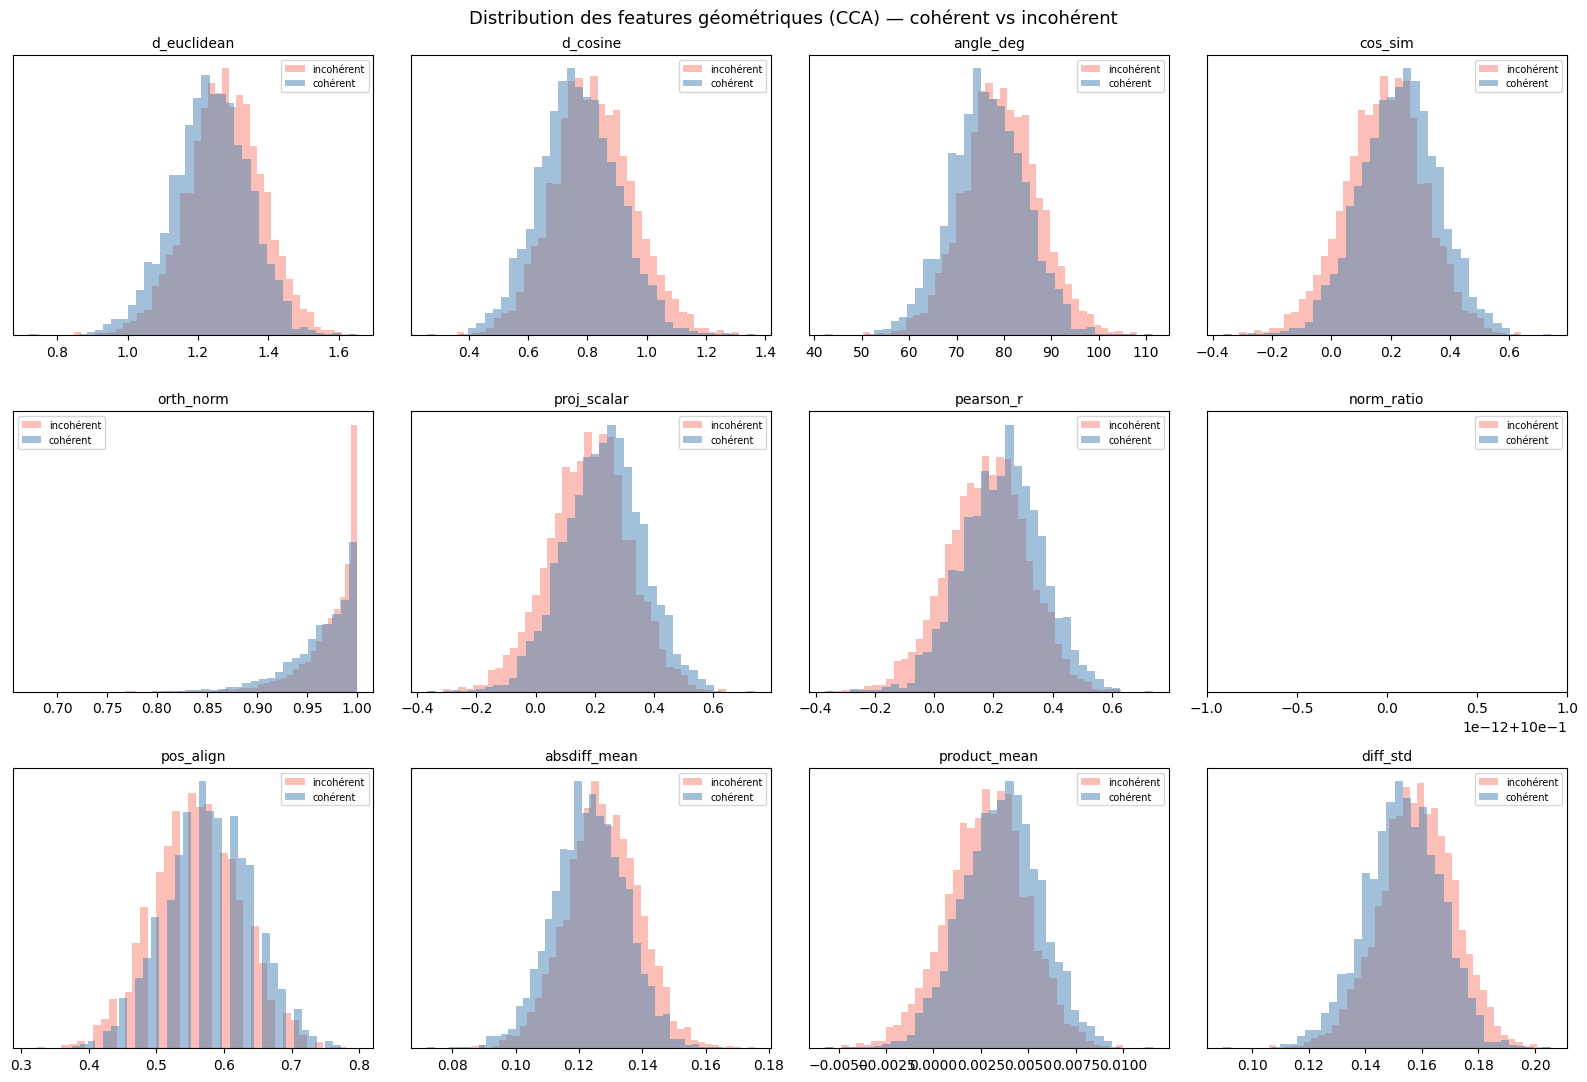

Sauvegardé : geo_distributions.png

Pouvoir discriminant AUC uni-varié (CCA) :
  pearson_r            AUC=0.6051  ██████████
  d_euclidean          AUC=0.6048  ██████████
  d_cosine             AUC=0.6048  ██████████
  angle_rad            AUC=0.6048  ██████████
  angle_deg            AUC=0.6048  ██████████
  cos_sim              AUC=0.6048  ██████████
  proj_scalar          AUC=0.6048  ██████████
  dot_product          AUC=0.6048  ██████████
  product_mean         AUC=0.6048  ██████████
  diff_std             AUC=0.6042  ██████████
  d_manhattan          AUC=0.6015  ██████████
  absdiff_mean         AUC=0.6015  ██████████
  orth_norm            AUC=0.5997  █████████
  pos_align            AUC=0.5807  ████████
  absdiff_std          AUC=0.5799  ███████
  d_chebyshev          AUC=0.5511  █████
  diff_max             AUC=0.5456  ████
  diff_min             AUC=0.5338  ███
  product_std          AUC=0.5327  ███
  ent_i                AUC=0.5121  █
  ent_t                AUC=0.5061  
  ent

In [9]:
# ═══════════════════════════════════════════════════════════════════
# Cell 9 — Visualisation des distributions géométriques
#
# L'idée de base : si les features géométriques séparent bien
# cohérent vs incohérent visuellement, le classifieur classique
# le fera encore mieux.
# ═══════════════════════════════════════════════════════════════════
# Indices des features scalaires dans le vecteur géométrique :
IDX = {
    'd_euclidean': 0, 'd_manhattan': 1, 'd_chebyshev': 2,
    'd_cosine': 3, 'angle_rad': 4, 'angle_deg': 5,
    'cos_sim': 6, 'proj_scalar': 7, 'orth_norm': 8,
    'norm_t': 9, 'norm_i': 10, 'norm_ratio': 11,
    'dot_product': 12,
    'diff_mean': 13, 'diff_std': 14, 'diff_max': 15, 'diff_min': 16,
    'pearson_r': 17,
    'ent_t': 18, 'ent_i': 19, 'ent_ratio': 20,
    'pos_align': 21,
    'product_mean': 22, 'product_std': 23,
    'absdiff_mean': 24, 'absdiff_std': 25,
}

proj_name = 'CCA'  # ou 'PLSCanonical', 'PLSSVD'
Xg_tr = GEO[proj_name]['X_tr']

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle(f'Distribution des features géométriques ({proj_name}) — cohérent vs incohérent', fontsize=13)

keys_to_plot = [
    'd_euclidean', 'd_cosine', 'angle_deg', 'cos_sim',
    'orth_norm', 'proj_scalar', 'pearson_r', 'norm_ratio',
    'pos_align', 'absdiff_mean', 'product_mean', 'diff_std',
]
colors = {0: 'salmon', 1: 'steelblue'}
labels = {0: 'incohérent', 1: 'cohérent'}

for ax, key in zip(axes.ravel(), keys_to_plot):
    idx = IDX[key]
    for lbl in [0, 1]:
        vals = Xg_tr[y_train==lbl, idx]
        ax.hist(vals, bins=40, alpha=0.5, color=colors[lbl],
                label=labels[lbl], density=True)
    ax.set_title(key, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('geo_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sauvegardé : geo_distributions.png')

# Calcul du pouvoir discriminant (AUC uni-varié)
print(f'\nPouvoir discriminant AUC uni-varié ({proj_name}) :')
aucs = {}
for key, idx in IDX.items():
    vals = Xg_tr[:, idx]
    try:
        auc = roc_auc_score(y_train, vals)
        auc = max(auc, 1-auc)  # toujours >= 0.5
    except Exception:
        auc = 0.5
    aucs[key] = auc

for k, v in sorted(aucs.items(), key=lambda x: -x[1]):
    bar = '█' * int((v-0.5)*100)
    print(f'  {k:<20} AUC={v:.4f}  {bar}')

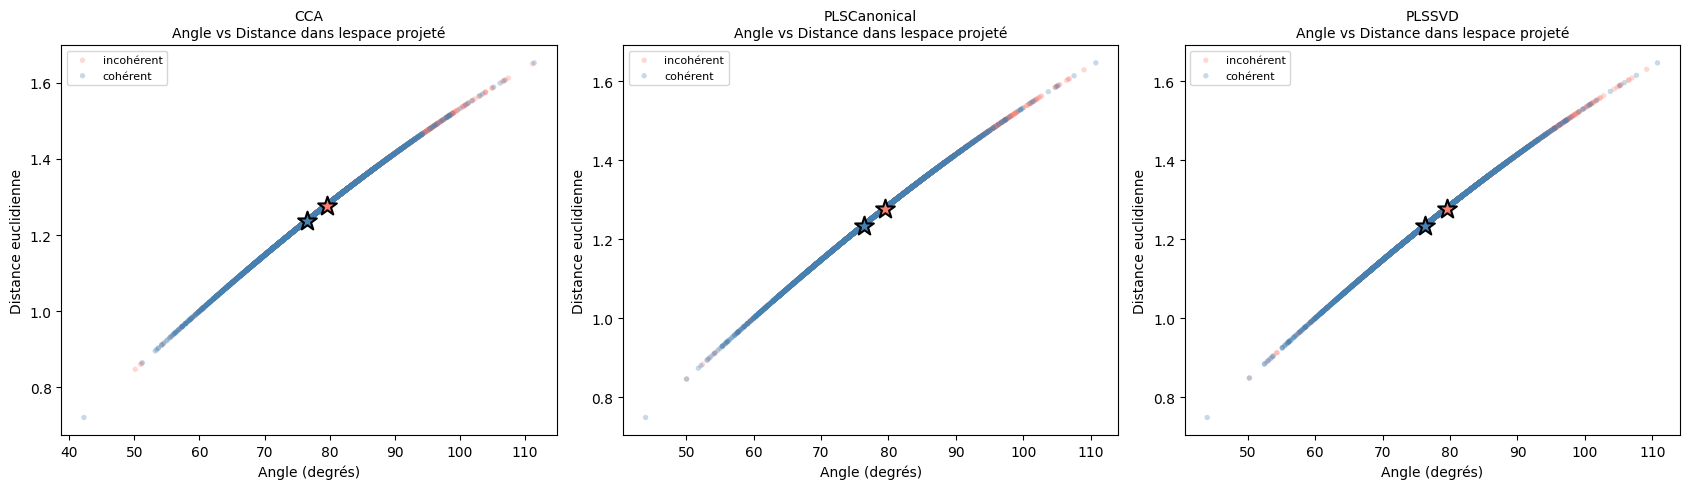


Statistiques géométriques par classe (CCA):
  angle_deg             incoh:  79.581±7.978  coh:  76.578±7.888  Cohen's d=0.379
  d_euclidean           incoh:   1.277±0.107  coh:   1.236±0.108  Cohen's d=0.378
  cos_sim               incoh:   0.179±0.136  coh:   0.230±0.133  Cohen's d=0.379
  orth_norm             incoh:   0.974±0.028  coh:   0.964±0.034  Cohen's d=0.337
  pearson_r             incoh:   0.179±0.137  coh:   0.230±0.134  Cohen's d=0.379
  pos_align             incoh:   0.558±0.066  coh:   0.576±0.065  Cohen's d=0.284


In [10]:
# ═══════════════════════════════════════════════════════════════════
# Cell 10 — Visualisation 2D de l'espace géométrique
#
# Scatter plot (angle, distance) pour voir si la séparation est linéaire.
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
proj_names = list(GEO.keys())

for ax, pname in zip(axes, proj_names):
    Xg = GEO[pname]['X_tr']
    angle = Xg[:, IDX['angle_deg']]
    dist  = Xg[:, IDX['d_euclidean']]
    cos   = Xg[:, IDX['cos_sim']]

    for lbl in [0, 1]:
        mask = y_train == lbl
        ax.scatter(angle[mask], dist[mask],
                   c=colors[lbl], label=labels[lbl],
                   alpha=0.3, s=15, edgecolors='none')

    # Centroïdes
    for lbl in [0, 1]:
        mask = y_train == lbl
        ax.scatter(angle[mask].mean(), dist[mask].mean(),
                   c=colors[lbl], s=200, marker='*',
                   edgecolors='black', linewidths=1.5, zorder=5)

    ax.set_xlabel('Angle (degrés)', fontsize=10)
    ax.set_ylabel('Distance euclidienne', fontsize=10)
    ax.set_title(f'{pname}\nAngle vs Distance dans lespace projeté', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('geo_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

# Statistiques descriptives par classe
print('\nStatistiques géométriques par classe (CCA):')
Xg = GEO['CCA']['X_tr']
for key in ['angle_deg','d_euclidean','cos_sim','orth_norm','pearson_r','pos_align']:
    idx = IDX[key]
    v0  = Xg[y_train==0, idx]
    v1  = Xg[y_train==1, idx]
    sep = abs(v0.mean() - v1.mean()) / (np.sqrt((v0.std()**2 + v1.std()**2)/2) + 1e-8)
    print(f'  {key:<20}  incoh: {v0.mean():7.3f}±{v0.std():.3f}  '
          f'coh: {v1.mean():7.3f}±{v1.std():.3f}  Cohen\'s d={sep:.3f}')

In [11]:
# ═══════════════════════════════════════════════════════════════════
# Cell 11 — Entraînement des classifieurs sur les features géométriques
#
# On teste plusieurs familles de modèles sur chaque projecteur.
# Métrique principale : F1 (plus juste vu le déséquilibre).
# ═══════════════════════════════════════════════════════════════════

CLASSIFIERS = {
    'LR':      LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced',
                                   n_jobs=-1, random_state=42),
    'LR C=5':  LogisticRegression(C=5.0, max_iter=2000, class_weight='balanced',
                                   n_jobs=-1, random_state=42),
    'RF':      RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                       n_jobs=-1, random_state=42),
    'SVM-RBF': CalibratedClassifierCV(
                   SVC(kernel='rbf', C=1.0, gamma='scale',
                       class_weight='balanced', random_state=42), cv=3),
    'KNN':     KNeighborsClassifier(n_neighbors=15, metric='euclidean', n_jobs=-1),
}

results_all = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Projector":<14} {"Classifieur":<12} {"CV-F1":>8} {"±":>5} {"Val-Acc":>8} {"Val-F1":>8}')
print('-'*60)

for pname in projectors:
    X_tr = GEO[pname]['X_tr']
    X_va = GEO[pname]['X_va']

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)
    GEO[pname]['scaler']  = sc
    GEO[pname]['X_tr_s']  = X_tr_s
    GEO[pname]['X_va_s']  = X_va_s

    for cname, clf in CLASSIFIERS.items():
        m = copy.deepcopy(clf)
        cv = cross_val_score(m, X_tr_s, y_train, cv=skf,
                              scoring='f1', n_jobs=-1)
        m.fit(X_tr_s, y_train)
        yp  = m.predict(X_va_s)
        acc = accuracy_score(y_val, yp)
        f1  = f1_score(y_val, yp)
        print(f'{pname:<14} {cname:<12} {cv.mean():>8.4f} {cv.std():>5.3f} {acc:>8.4f} {f1:>8.4f}')
        results_all.append({
            'projector': pname, 'clf': cname,
            'cv_f1': cv.mean(), 'val_acc': acc, 'val_f1': f1,
            'model': m, 'scaler': sc,
        })
    print()

Projector      Classifieur     CV-F1     ±  Val-Acc   Val-F1
------------------------------------------------------------
CCA            LR             0.6614 0.014   0.6313   0.5635
CCA            LR C=5         0.6617 0.013   0.6313   0.5642
CCA            RF             0.6664 0.014   0.6147   0.4848
CCA            SVM-RBF        0.6602 0.022   0.6247   0.5200
CCA            KNN            0.6230 0.009   0.5633   0.5094

PLSCanonical   LR             0.6632 0.016   0.6327   0.5678
PLSCanonical   LR C=5         0.6620 0.016   0.6307   0.5658
PLSCanonical   RF             0.6625 0.019   0.6020   0.4548
PLSCanonical   SVM-RBF        0.6554 0.016   0.6207   0.5133
PLSCanonical   KNN            0.6207 0.005   0.5640   0.5226

PLSSVD         LR             0.6630 0.014   0.6307   0.5685
PLSSVD         LR C=5         0.6634 0.014   0.6300   0.5674
PLSSVD         RF             0.6574 0.019   0.5927   0.4430
PLSSVD         SVM-RBF        0.6539 0.015   0.6233   0.5191
PLSSVD         KNN    

In [14]:
from sklearn.cross_decomposition import PLSSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import numpy as np

# ------------------------------------------------------------
# Fusionner les ensembles d'entraînement et de validation
# ------------------------------------------------------------
text_all = np.vstack([Pt_tr, Pt_va])   # texte après SVD
img_all  = np.vstack([Pi_tr, Pi_va])   # image après PCA
y_all    = np.hstack([y_train, y_val]) # étiquettes

# Grille de paramètres
param_grid = {
    'n_components': [10, 20, 30, 40, 50],
    'C': [0.1, 1, 10, 100],
    'penalty': ['l2']
}

best_score = -1
best_params = None

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# Validation croisée manuelle (chaque pli ré‑estime PLSSVD)
# ------------------------------------------------------------
for n_comp in param_grid['n_components']:
    for C in param_grid['C']:
        for penalty in param_grid['penalty']:
            fold_scores = []
            for train_idx, val_idx in kf.split(text_all):
                # Séparer les données du pli
                text_tr = text_all[train_idx]
                img_tr  = img_all[train_idx]
                y_tr    = y_all[train_idx]
                text_va = text_all[val_idx]
                img_va  = img_all[val_idx]
                y_va    = y_all[val_idx]

                # 1) PLSSVD sur les données d'entraînement
                pls = PLSSVD(n_components=n_comp)
                pls.fit(text_tr, img_tr)

                # 2) Projection des deux vues -> scores X et Y, puis concaténation
                x_tr, y_tr_proj = pls.transform(text_tr, img_tr)
                X_tr_proj = np.hstack([x_tr, y_tr_proj])
                x_va, y_va_proj = pls.transform(text_va, img_va)
                X_va_proj = np.hstack([x_va, y_va_proj])

                # 3) Régression logistique
                lr = LogisticRegression(C=C, penalty=penalty, max_iter=1000, random_state=42)
                lr.fit(X_tr_proj, y_tr)
                y_pred = lr.predict(X_va_proj)
                fold_scores.append(f1_score(y_va, y_pred, average='weighted'))

            mean_f1 = np.mean(fold_scores)
            if mean_f1 > best_score:
                best_score = mean_f1
                best_params = {'n_components': n_comp, 'C': C, 'penalty': penalty}

print(f"Meilleurs paramètres : {best_params}")
print(f"Meilleur F1 moyen (CV) : {best_score:.4f}")

# ------------------------------------------------------------
# Ré‑entraînement final sur tout l'ensemble (train+val)
# ------------------------------------------------------------
best_pls = PLSSVD(n_components=best_params['n_components'])
best_pls.fit(text_all, img_all)
x_all, y_all_proj = best_pls.transform(text_all, img_all)
X_all_proj = np.hstack([x_all, y_all_proj])
best_lr = LogisticRegression(C=best_params['C'], penalty=best_params['penalty'], max_iter=1000)
best_lr.fit(X_all_proj, y_all)

# ------------------------------------------------------------
# Évaluation sur le jeu de test
# ------------------------------------------------------------
x_test, y_test_proj = best_pls.transform(Pt_te, Pi_te)
X_test_proj = np.hstack([x_test, y_test_proj])
y_pred_test = best_lr.predict(X_test_proj)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
print(f"F1 sur le test : {test_f1:.4f}")

Meilleurs paramètres : {'n_components': 20, 'C': 10, 'penalty': 'l2'}
Meilleur F1 moyen (CV) : 0.4774
F1 sur le test : 0.4785


In [12]:
# ═══════════════════════════════════════════════════════════════════
# Cell 12 — Ajustement du seuil de décision
# ═══════════════════════════════════════════════════════════════════
# Meilleur modèle sur F1 validation
best = max(results_all, key=lambda r: r['val_f1'])
print(f'Meilleur modèle : {best['projector']} + {best['clf']}')
print(f'Val F1@0.5      : {best['val_f1']:.4f}')

BEST_PROJ  = best['projector']
BEST_MODEL = best['model']
BEST_SC    = best['scaler']
X_va_best  = GEO[BEST_PROJ]['X_va_s']
X_te_best  = BEST_SC.transform(GEO[BEST_PROJ]['X_te'])

if hasattr(BEST_MODEL, 'predict_proba'):
    proba_va = BEST_MODEL.predict_proba(X_va_best)[:,1]
    proba_te = BEST_MODEL.predict_proba(X_te_best)[:,1]
else:
    proba_va = proba_te = None

BEST_THRESH = 0.5
if proba_va is not None:
    p, r, th = precision_recall_curve(y_val, proba_va)
    f1s = 2*p*r/(p+r+1e-8)
    bi = np.argmax(f1s[:-1])
    BEST_THRESH = float(th[bi])
    print(f'Seuil optimal   : {BEST_THRESH:.4f}')
    print(f'Val F1@opt      : {f1s[bi]:.4f}')
    print(f'Val Acc@opt     : {accuracy_score(y_val,(proba_va>=BEST_THRESH).astype(int)):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(th, f1s[:-1], color='steelblue')
    axes[0].axvline(BEST_THRESH, color='crimson', linestyle='--', label=f'opt={BEST_THRESH:.3f}')
    axes[0].axvline(0.5, color='gray', linestyle=':', label='0.5')
    axes[0].set_xlabel('Seuil'); axes[0].set_ylabel('F1')
    axes[0].set_title('F1 vs seuil (validation)'); axes[0].legend()

    axes[1].hist(proba_va[y_val==0],bins=40,alpha=0.5,color='salmon',label='incohérent',density=True)
    axes[1].hist(proba_va[y_val==1],bins=40,alpha=0.5,color='steelblue',label='cohérent',density=True)
    axes[1].axvline(BEST_THRESH,color='crimson',linestyle='--')
    axes[1].set_xlabel('P(cohérent)'); axes[1].set_title('Distribution proba')
    axes[1].legend()
    plt.tight_layout(); plt.show()

SyntaxError: f-string: unmatched '[' (3642182885.py, line 6)